# Import Required Libraries

Import PyTorch and its neural network module.

In [2]:
import torch
import torch.nn as nn

# Define the LeNet-5 Model Class

Create a class that inherits from nn.Module and defines the LeNet-5 architecture with convolutional and fully connected layers.

In [3]:
class LeNet5(nn.Module):
    """
    Implementation of the classic LeNet-5 convolutional neural network.

    Architecture overview:
    - Input: grayscale image (1 channel), typically 32x32
    - Conv1 -> ReLU -> AvgPool
    - Conv2 -> ReLU -> AvgPool
    - Conv3 -> ReLU
    - Fully connected (FC1) -> ReLU
    - Fully connected (FC2) -> output logits (10 classes)

    Commonly used for digit classification (e.g., MNIST).
    """

    def __init__(self):
        """
        Initialize all layers of the network.
        """
        super(LeNet5, self).__init__()

        # First convolutional layer:
        # Input: 1 channel (grayscale), Output: 6 feature maps
        # Kernel size: 5x5
        # Stride = how many pixels the filter jumps each step.
        # Padding = adding pixels (usually zeros) around the input.
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=2, padding=2)

        # Average pooling layer:
        # Reduces spatial dimensions by factor of 2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional layer:
        # Input: 6 channels, Output: 16 feature maps
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        # Third convolutional layer:
        # Input: 16 channels, Output: 120 feature maps
        # This effectively prepares data for the fully connected layers
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)

        # First fully connected layer:
        # Input features: 120, Output: 84
        self.fc1 = nn.Linear(120, 84)

        # Final fully connected layer:
        # Output: 10 classes (e.g., digits 0–9)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        """
        Define the forward pass of the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 1, H, W)

        Returns:
            torch.Tensor: Output logits of shape (batch_size, 10)
        """

        # First block: Conv1 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv1(x)))

        # Second block: Conv2 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x)))

        # Third convolution + activation
        x = torch.relu(self.conv3(x))

        # Flatten tensor for fully connected layers
        # -1 means infer batch size automatically
        x = x.view(-1, 120)

        # First fully connected layer + activation
        x = torch.relu(self.fc1(x))

        # Final layer (no activation here, since logits are expected)
        x = self.fc2(x)

        return x

# Instantiate the Model

Create an instance of the LeNet-5 model.

In [4]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


# Visualize Conv1 filters (before training)

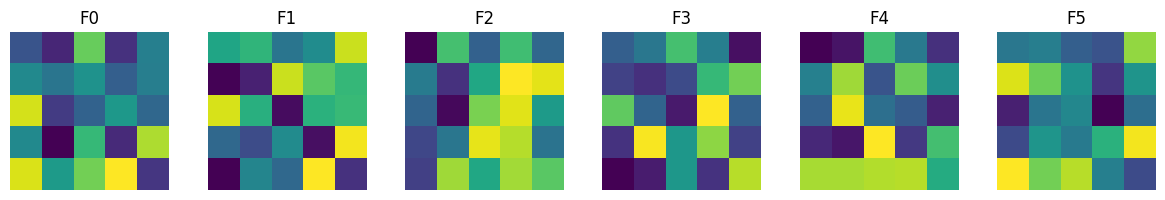

In [5]:
import matplotlib.pyplot as plt

def show_conv1_filters(model):
    """
    Displays the filters of the first convolutional layer.
    Should be called BEFORE training to see initial state.
    """
    # Get weights: shape (out_channels, in_channels, H, W)
    weights = model.conv1.weight.data.clone()

    # Normalize weights for visualization (0–1 range)
    weights = (weights - weights.min()) / (weights.max() - weights.min())

    num_filters = weights.shape[0]

    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 2))

    for i in range(num_filters):
        # Since input is grayscale, we take channel 0
        filter_img = weights[i, 0].cpu().numpy()

        axes[i].imshow(filter_img)
        axes[i].axis('off')
        axes[i].set_title(f'F{i}')

    plt.tight_layout()
    plt.show()


# Usage
show_conv1_filters(model)

# Load MNIST + Show examples

100.0%
100.0%
100.0%
100.0%


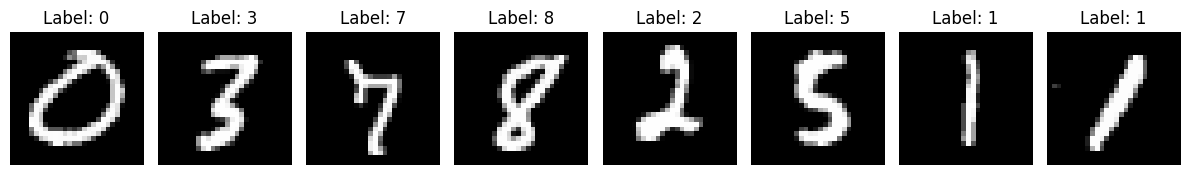

In [6]:
from torchvision import datasets, transforms

# Transform: convert images to tensor
transform = transforms.ToTensor()

# Load MNIST dataset (downloads automatically if not present)
mnist = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Create a DataLoader
loader = torch.utils.data.DataLoader(mnist, batch_size=8, shuffle=True)

# Get one batch
images, labels = next(iter(loader))

# Plot images
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    img = images[i].squeeze()  # remove channel dimension (1, 28, 28) → (28, 28)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()